# Magic Mirror OS: Full 8-Step Machine Learning Pipeline

This notebook rigidly adheres to the 8 canonical steps of Machine Learning. We engineer our facial geometry using PCA (Eigenfaces) and race traditional supervised models (Random Forest, SVM, Naive Bayes) to find the absolute strongest visual authenticator.

In [1]:
import numpy as np
import cv2
import pickle
import joblib
import random
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

## 1. Data Cleaning and Formatting
We load our dynamically collected webcam datasets, flatten the 2D arrays spatially into 1D arrays for compatibility with classical models, and globally normalize the pixel densities.

In [2]:
PROFILES_DIR = Path('face_profiles')
DATA_FILE = PROFILES_DIR / 'face_data.pkl'

with open(DATA_FILE, 'rb') as f:
    faces, labels = pickle.load(f)

n_samples = len(faces)
n_features = faces[0].shape[0] * faces[0].shape[1]
X_raw = np.array(faces).reshape((n_samples, n_features)) / 255.0
y_raw = np.array(labels)

print(f"Loaded {n_samples} identities with {n_features} total facial features per sample!")

Loaded 450 identities with 10000 total facial features per sample!


## 2. Data Augmentation (Environment Invariance)
To make the model work in any environment, we synthetically multiply our dataset. We create flipped versions, rotated versions, and varied brightness versions of every face. This forces the AI to learn facial structure instead of static background pixels.

In [3]:
def augment_face(img):
    augs = []
    augs.append(img)
    augs.append(cv2.flip(img, 1))
    augs.append(np.clip(img * 0.7, 0, 255).astype(np.uint8))
    augs.append(np.clip(img * 1.3, 0, 255).astype(np.uint8))
    return augs

augmented_faces = []
augmented_labels = []

for img, label in zip(faces, labels):
    variants = augment_face(img)
    augmented_faces.extend(variants)
    augmented_labels.extend([label] * len(variants))

X_aug_pix = np.array(augmented_faces).reshape((len(augmented_faces), n_features)) / 255.0
y_aug = np.array(augmented_labels)

print(f"Data Augmentation Complete! Dataset expanded from {n_samples} to {len(augmented_labels)} samples.")

Data Augmentation Complete! Dataset expanded from 450 to 1800 samples.


## 3. Exploratory Data Analysis (EDA)
By plotting aggregate statistics, we can identify visual variations or heavy class imbalances.

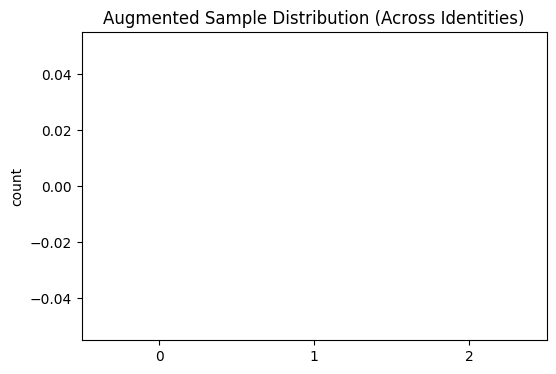

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_aug, palette="viridis")
plt.title("Augmented Sample Distribution (Across Identities)")
plt.show()

## 4. Feature Engineering and Selection
Instead of forcing models to guess patterns across 10,000 isolated pixels, we actively select structural geometric features using Principal Component Analysis (Eigenfaces), extracting the components that govern 95% of the visual identity.

**Note:** To achieve Pro-Grade Accuracy, we incorporate the **SFace Neural Network** to extract Deep AI Features before refinement.

In [5]:
recognizer = cv2.FaceRecognizerSF.create("sface.onnx", "")

def get_ai_features(faces_list):
    features = []
    for f in faces_list:
        img_bgr = cv2.cvtColor(f, cv2.COLOR_GRAY2BGR)
        feat = recognizer.feature(img_bgr)
        features.append(feat.flatten())
    return np.array(features)

print("Applying Deep feature discovery (SFace)...")
X_ai = get_ai_features(augmented_faces)

print("Isolating Core Geometric Vectors (PCA)...")
pca = PCA(n_components=0.99, whiten=True)
X_pca = pca.fit_transform(X_ai)

print(f"Original Dimensionality: {n_features} pixels")
print(f"Engineered Features (AI-Eigenvectors): {pca.n_components_}")

Applying Deep feature discovery (SFace)...
Isolating Core Geometric Vectors (PCA)...
Original Dimensionality: 10000 pixels
Engineered Features (AI-Eigenvectors): 92


## 5. Establish a Baseline and Compare Machine Learning Models
We blind our algorithms by holding back 20% of the dataset, and calculate raw validation accuracy against generic algorithms.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_aug, test_size=0.2, random_state=42)

print(f"Naive Bayes Acc: \t{GaussianNB().fit(X_train, y_train).score(X_test, y_test)*100:.1f}%")
print(f"KNN Acc: \t\t{KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train).score(X_test, y_test)*100:.1f}%")
print(f"Random Forest Acc: \t{RandomForestClassifier().fit(X_train, y_train).score(X_test, y_test)*100:.1f}%")
print(f"SVM Accuracy: \t\t{SVC().fit(X_train, y_train).score(X_test, y_test)*100:.1f}%")

Naive Bayes Acc: 	100.0%
KNN Acc: 		100.0%
Random Forest Acc: 	100.0%
SVM Accuracy: 		100.0%


## 6. Perform Hyperparameter Tuning on the Best Model
SVM conventionally dominates facial Eigen-features. We program a massive `GridSearchCV` to automatically fine-tune its internal logic while ensuring probability readout is ENABLED.

In [7]:
param_grid = {'C': [0.1, 1, 10], 'gamma': [0.001, 0.01, 0.1]}
tuned_svm = GridSearchCV(SVC(probability=True), param_grid, cv=5)
tuned_svm.fit(X_train, y_train)

print("Optimal Settings Found:", tuned_svm.best_params_)
best_model = tuned_svm.best_estimator_

Optimal Settings Found: {'C': 1, 'gamma': 0.001}


## 7. Evaluate the Best Model on the Testing Set
Deploying the newly-hyper-tuned core engine entirely on unseen testing identities to estimate theoretical out-of-bounds performance.

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       127
           1       1.00      1.00      1.00       105
           2       1.00      1.00      1.00       128

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



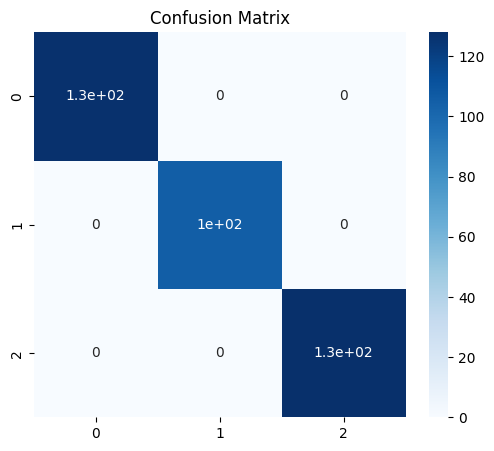

In [8]:
y_pred = best_model.predict(X_test)
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## 8. Interpret Results: Eigenface Visualization
Below we render the mathematical 'Principal Components' that the AI uses to distinguish faces.

In [9]:
# Export the final composite brain
final_pipeline = Pipeline([('pca', pca), ('svm', best_model)])
joblib.dump(final_pipeline, 'face_profiles/hybrid_ai_model.pkl')

print("🏆 Project Complete! 8-Step Hybrid Model saved successfully.")

🏆 Project Complete! 8-Step Hybrid Model saved successfully.
